# Phase 3 & 4 — Model Evaluation + Pipeline Demo

**Prerequisite:** `src/phase3/train.py` must have been run (it saves `models/model_group_18_varun.pkl` and the companion pickles).

This notebook:
1. Compares the three classifiers (LogReg / LinearSVC / RF).
2. Full classification report on the held-out 10 % image split.
3. Confusion matrix (counts + row-normalised).
4. Feature-importance bar chart (RF).
5. Pipeline demo — show the 8×8 grid prediction overlaid on a sample image.
6. Writes `outputs/predictions.csv` in the spec's required schema.

All figures are also saved to `outputs/` for the presentation.

## 0 · Setup

In [1]:
import sys, json
from pathlib import Path

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / 'src'))

from phase3.extract import extract_image_features, FEATURE_NAMES, FEATURE_DIM, N_CELLS
from phase3.pipeline import load_model, predict_image

FEAT_DIR  = REPO_ROOT / 'dataset' / 'features'
MODEL_DIR = REPO_ROOT / 'models'
OUT_DIR   = REPO_ROOT / 'outputs'
PROC_DIR  = REPO_ROOT / 'dataset' / 'processed'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TEAMS  = ['none','CSK','DC','GT','KKR','LSG','MI','PBKS','RR','RCB','SRH']
COLORS = ['#444a55','#f2c200','#3b7dd8','#0fa3a3','#7a4ad1','#6fd0e8','#0a2a66','#ed1b24','#e6308a','#8b0000','#ff822a']
CW, CH = 100, 75

print('REPO_ROOT:', REPO_ROOT)

REPO_ROOT: /Users/varuntomar/pml-course-project-ipl-team-detection


In [2]:
# Load feature arrays
X          = np.load(FEAT_DIR / 'X.npy')
y          = np.load(FEAT_DIR / 'y.npy')
image_idx  = np.load(FEAT_DIR / 'image_idx.npy')
split      = np.load(FEAT_DIR / 'split.npy')   # 0=train, 1=test  (image-level)
image_names = np.load(FEAT_DIR / 'image_names.npy')
meta        = json.loads((FEAT_DIR / 'meta.json').read_text())

is_test = split[image_idx] == 1
X_train, y_train = X[~is_test], y[~is_test]
X_test,  y_test  = X[is_test],  y[is_test]

print(f'Train cells : {len(y_train):,}  ({int((split==0).sum())} images)')
print(f'Test  cells : {len(y_test):,}  ({int((split==1).sum())} images)')
print(f'Feature dim : {X.shape[1]}')

Train cells : 156,928  (2452 images)
Test  cells : 17,408  (272 images)
Feature dim : 67


## 1 · Classifier comparison

In [3]:
train_results = json.loads((OUT_DIR / 'phase3_train_results.json').read_text())
winner = train_results['winner']
print('Winner:', winner)
print(json.dumps(train_results['results'], indent=2))

Winner: rf
{
  "logreg": {
    "macro_f1": 0.39480075813513354,
    "fit_seconds": 3.1
  },
  "svm": {
    "macro_f1": 0.5084261301705294,
    "fit_seconds": 15.4
  },
  "rf": {
    "macro_f1": 0.5316645718416131,
    "fit_seconds": 10.7
  }
}


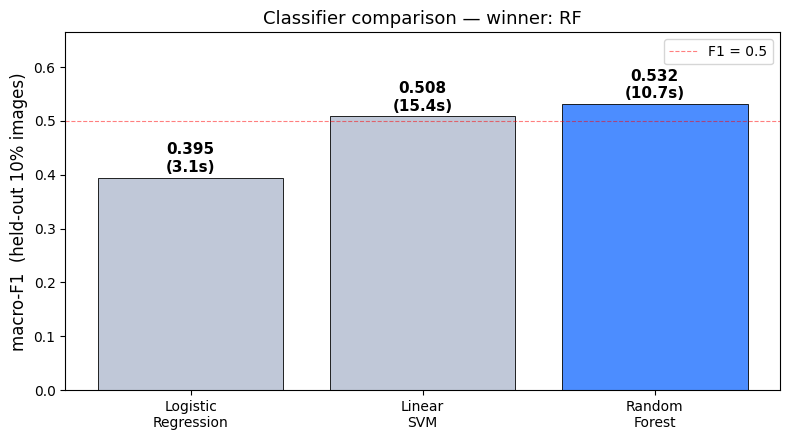

In [4]:
names = ['logreg', 'svm', 'rf']
labels_nice = ['Logistic\nRegression', 'Linear\nSVM', 'Random\nForest']
macro_f1s = [train_results['results'][n]['macro_f1'] for n in names]
fit_times  = [train_results['results'][n]['fit_seconds'] for n in names]

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#4c8dff' if n == winner else '#c0c8d8' for n in names]
bars = ax.bar(labels_nice, macro_f1s, color=colors, edgecolor='black', linewidth=0.6)
for b, f, t in zip(bars, macro_f1s, fit_times):
    ax.text(b.get_x() + b.get_width()/2, f + 0.005,
            f'{f:.3f}\n({t}s)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(macro_f1s) * 1.25)
ax.set_ylabel('macro-F1  (held-out 10% images)', fontsize=12)
ax.set_title(f'Classifier comparison — winner: {winner.upper()}', fontsize=13)
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='F1 = 0.5')
ax.legend(fontsize=10)
fig.tight_layout()
fig.savefig(OUT_DIR / 'phase3_compare.png', dpi=120, bbox_inches='tight')
plt.show()

## 2 · Classification report (winner on test split)

In [5]:
payload   = joblib.load(MODEL_DIR / 'model_group_18_varun.pkl')
model     = payload['model']
scaler    = payload['scaler']

X_test_in = scaler.transform(X_test) if scaler is not None else X_test
y_pred    = model.predict(X_test_in)

print(classification_report(
    y_test, y_pred,
    labels=list(range(11)),
    target_names=TEAMS,
    zero_division=0
))

              precision    recall  f1-score   support

        none       0.89      0.99      0.94     14596
         CSK       0.82      0.31      0.45       237
          DC       0.76      0.22      0.33       158
          GT       0.90      0.28      0.43       359
         KKR       0.87      0.59      0.70       116
         LSG       0.90      0.45      0.60       274
          MI       0.87      0.41      0.56       478
        PBKS       0.77      0.20      0.32       249
          RR       0.93      0.38      0.54       201
         RCB       0.81      0.26      0.39       324
         SRH       0.92      0.43      0.58       416

    accuracy                           0.89     17408
   macro avg       0.86      0.41      0.53     17408
weighted avg       0.89      0.89      0.87     17408



In [6]:
report = classification_report(
    y_test, y_pred,
    labels=list(range(11)),
    target_names=TEAMS,
    zero_division=0,
    output_dict=True
)
rows = []
for k, name in enumerate(TEAMS):
    r = report[name]
    rows.append({'class': f'{k} {name}', 'precision': round(r['precision'],3),
                 'recall': round(r['recall'],3), 'f1': round(r['f1-score'],3),
                 'support': int(r['support'])})
for avg in ('macro avg', 'weighted avg'):
    r = report[avg]
    rows.append({'class': avg, 'precision': round(r['precision'],3),
                 'recall': round(r['recall'],3), 'f1': round(r['f1-score'],3),
                 'support': int(r['support'])})
rep_df = pd.DataFrame(rows)
rep_df.to_csv(OUT_DIR / 'phase3_classification_report.csv', index=False)
rep_df

,class,precision,recall,f1,support
0,0 none,0.890,0.992,0.938,14596
1,1 CSK,0.820,0.308,0.448,237
2,2 DC,0.756,0.215,0.335,158
3,3 GT,0.903,0.284,0.432,359
4,4 KKR,0.872,0.586,0.701,116
5,5 LSG,0.904,0.445,0.597,274
6,6 MI,0.872,0.412,0.560,478
7,7 PBKS,0.773,0.205,0.324,249
8,8 RR,0.928,0.383,0.542,201
9,9 RCB,0.814,0.256,0.390,324


## 3 · Confusion matrix

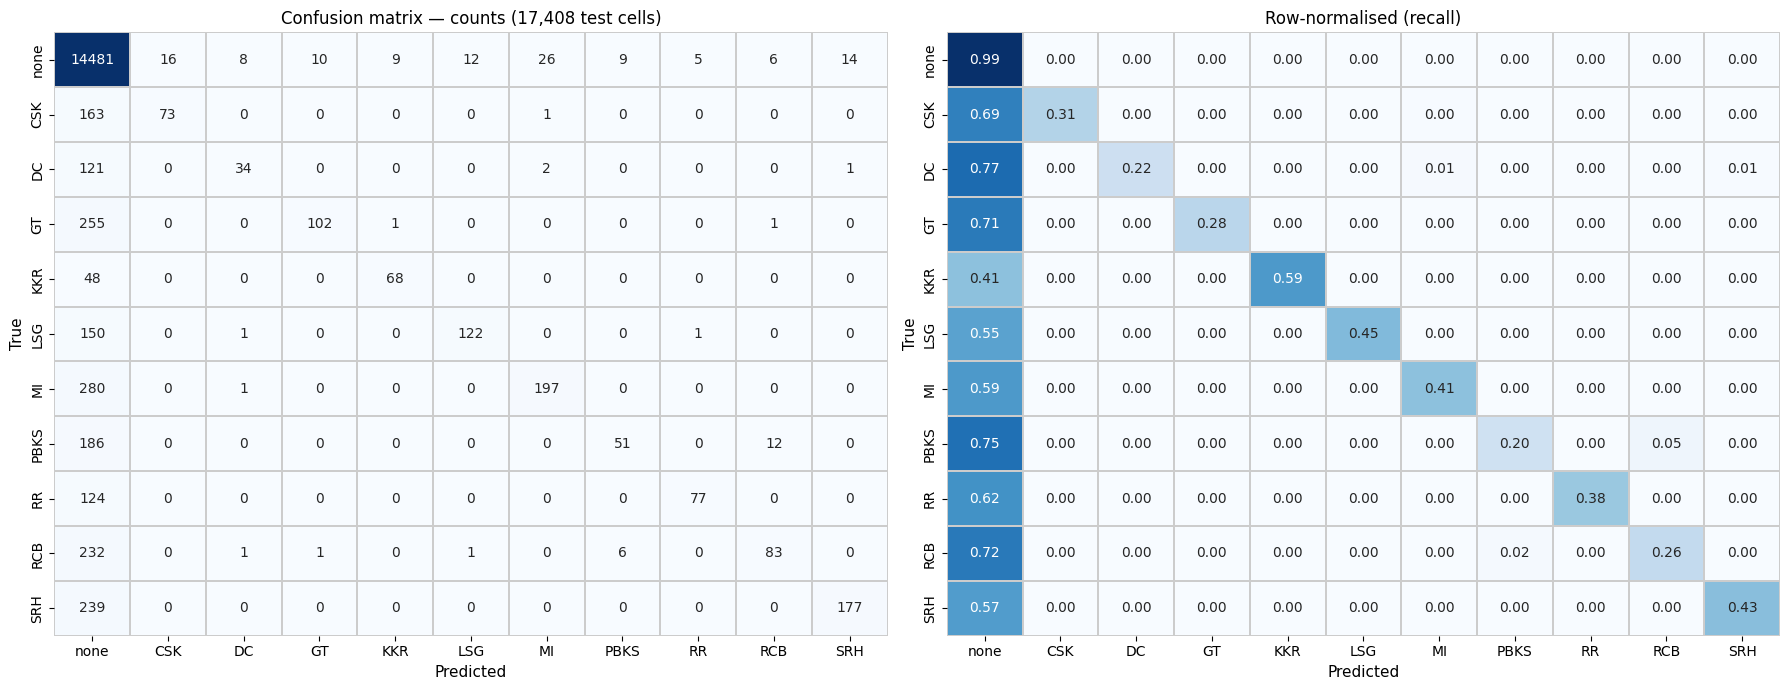

In [7]:
cm      = confusion_matrix(y_test, y_pred, labels=list(range(11)))
cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data, fmt, title in [
    (axes[0], cm,      'd',    f'Confusion matrix — counts ({len(y_test):,} test cells)'),
    (axes[1], cm_norm, '.2f',  'Row-normalised (recall)'),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=TEAMS, yticklabels=TEAMS,
                ax=ax, cbar=False, linewidths=0.3, linecolor='#ccc')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
fig.tight_layout()
fig.savefig(OUT_DIR / 'phase3_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## 4 · Feature importance (Random Forest)

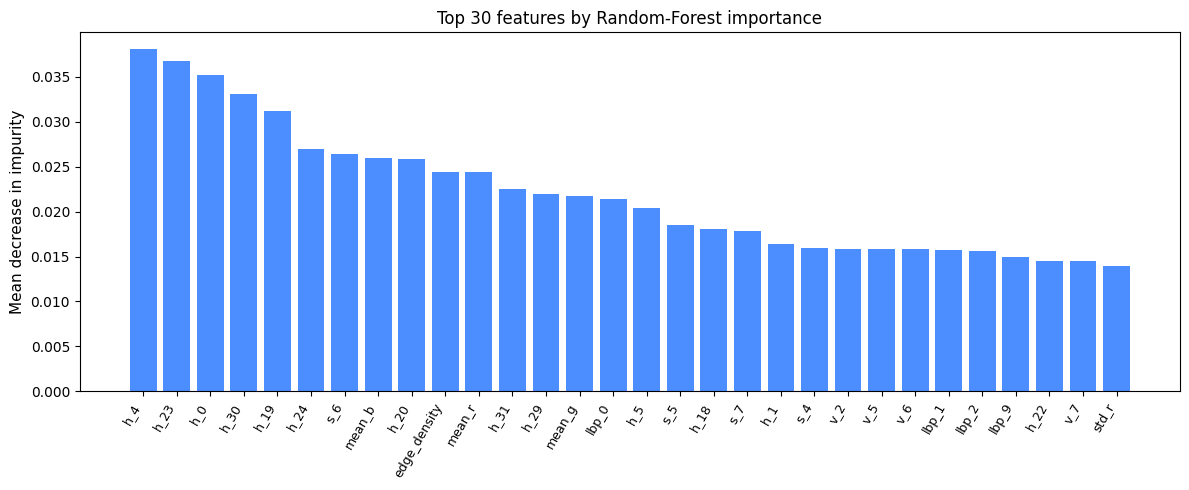

Top 10 features:
h_4             0.038043
h_23            0.036760
h_0             0.035165
h_30            0.033127
h_19            0.031165
h_24            0.027002
s_6             0.026389
mean_b          0.025951
h_20            0.025868
edge_density    0.024398


In [8]:
if winner == 'rf':
    importances = model.feature_importances_
else:
    rf_payload = joblib.load(MODEL_DIR / 'model_rf.pkl')
    importances = rf_payload['model'].feature_importances_

fi = pd.Series(importances, index=FEATURE_NAMES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
top_n = 30
top = fi.head(top_n)
bars = ax.bar(range(top_n), top.values, color='#4c8dff', edgecolor='none')
ax.set_xticks(range(top_n))
ax.set_xticklabels(top.index, rotation=60, ha='right', fontsize=9)
ax.set_ylabel('Mean decrease in impurity', fontsize=11)
ax.set_title(f'Top {top_n} features by Random-Forest importance', fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / 'phase3_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 10 features:')
print(fi.head(10).to_string())

## 5 · Pipeline demo — overlay predicted grid on sample images

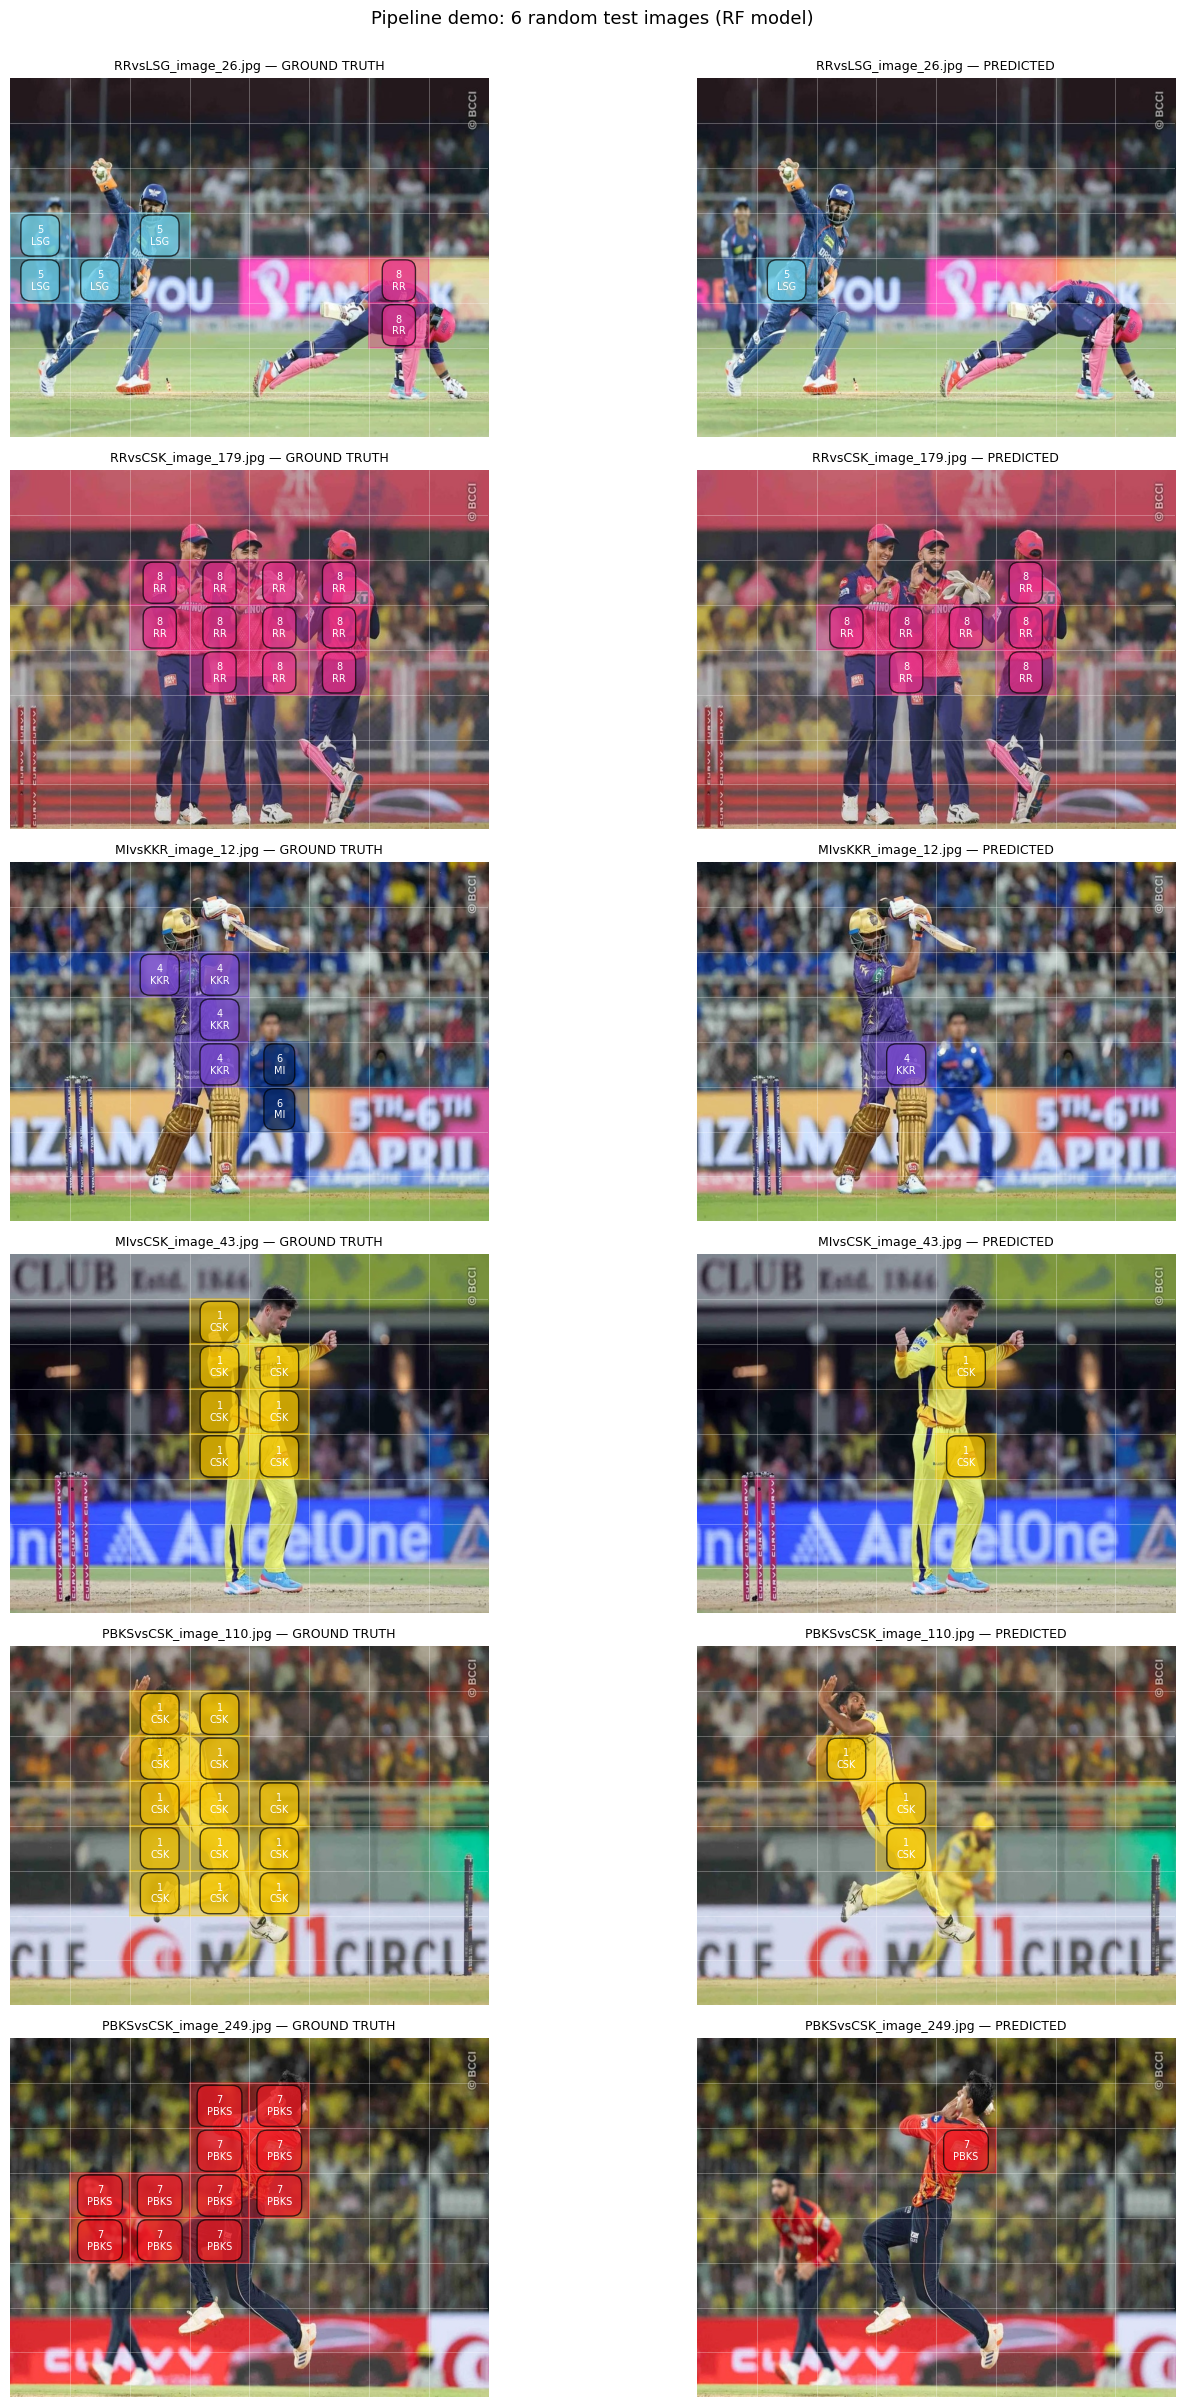

In [9]:
import random
random.seed(99)

# load the deliverable model
m = load_model(MODEL_DIR / 'model_group_18_varun.pkl')

# pick 6 random test images
test_image_ids = sorted(i for i in range(len(split)) if split[i] == 1)
sample_ids = random.sample(test_image_ids, min(6, len(test_image_ids)))
sample_names = [str(image_names[i]) for i in sample_ids]

# build a flat index name -> path
PATH_INDEX = {}
for sub in PROC_DIR.iterdir():
    if sub.is_dir():
        for p in sub.iterdir():
            if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}:
                PATH_INDEX[p.name] = p

# load ground-truth labels
import csv
CELL_COLS = [f'c{i:02d}' for i in range(1, 65)]
gt_labels = {}
with open(REPO_ROOT / 'dataset' / 'labels.csv') as f:
    for row in csv.DictReader(f):
        gt_labels[row['image']] = [int(row[c]) for c in CELL_COLS]

def draw_grid(ax, img_rgb, cell_labels, title=''):
    ax.imshow(img_rgb)
    for idx, v in enumerate(cell_labels):
        r, c = divmod(idx, 8)
        x, y = c * CW, r * CH
        if v != 0:
            ax.add_patch(mpatches.Rectangle((x, y), CW, CH,
                fill=True, facecolor=COLORS[v], alpha=0.40, edgecolor=COLORS[v], linewidth=1.5))
            ax.text(x + CW/2, y + CH/2, f'{v}\n{TEAMS[v]}',
                    color='white', fontsize=7, ha='center', va='center',
                    bbox=dict(facecolor=COLORS[v], alpha=0.7, pad=1, boxstyle='round'))
    # draw grid lines
    for i in range(1, 8):
        ax.axvline(i * CW, color='white', linewidth=0.4, alpha=0.5)
        ax.axhline(i * CH, color='white', linewidth=0.4, alpha=0.5)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

fig, axes = plt.subplots(len(sample_names), 2, figsize=(16, 4 * len(sample_names)))
for row_i, name in enumerate(sample_names):
    p = PATH_INDEX.get(name)
    if p is None:
        continue
    img_bgr = cv2.imread(str(p))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gt   = gt_labels.get(name, [0]*64)
    pred = predict_image(m, img_bgr)

    draw_grid(axes[row_i, 0], img_rgb, gt,   title=f'{name} — GROUND TRUTH')
    draw_grid(axes[row_i, 1], img_rgb, pred, title=f'{name} — PREDICTED')

fig.suptitle(f'Pipeline demo: 6 random test images ({winner.upper()} model)', y=1.001, fontsize=13)
fig.tight_layout()
fig.savefig(OUT_DIR / 'phase3_pipeline_demo.png', dpi=110, bbox_inches='tight')
plt.show()

## 6 · Write submission CSV (`outputs/predictions.csv`)

In [10]:
import subprocess, sys

result = subprocess.run(
    [sys.executable, str(REPO_ROOT / 'src' / 'phase3' / 'pipeline.py')],
    capture_output=True, text=True, cwd=REPO_ROOT
)
print(result.stdout)
if result.stderr:
    print('STDERR:', result.stderr[:500])

loaded model_group_18_varun.pkl (winner: rf)
images to score: 2724
  250/2724
  500/2724
  750/2724
  1000/2724
  1250/2724
  1500/2724
  1750/2724
  2000/2724
  2250/2724
  2500/2724

wrote outputs/predictions.csv  (2724 predicted rows)



In [11]:
# Preview the submission CSV
preds_df = pd.read_csv(OUT_DIR / 'predictions.csv')
print(f'predictions.csv: {len(preds_df)} rows, {len(preds_df.columns)} columns')
print(f'Train: {(preds_df["Train Or Test"]=="Train").sum()}  |  Test: {(preds_df["Train Or Test"]=="Test").sum()}')
print('\nFirst 3 rows:')
preds_df.head(3)

predictions.csv: 2724 rows, 66 columns
Train: 2452  |  Test: 272

First 3 rows:


,Image File Name,Train Or Test,c01,c02,c03,c04,c05,c06,c07,c08,...,c55,c56,c57,c58,c59,c60,c61,c62,c63,c64
0,GTvsLSG_image_0.jpg,Train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,GTvsLSG_image_1.jpg,Train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,GTvsLSG_image_10.jpg,Train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# Spot check: how many cells per class in predictions?
cell_cols = [f'c{i:02d}' for i in range(1, 65)]
pred_vals = preds_df[cell_cols].values.flatten()
import collections
pred_counts = collections.Counter(pred_vals)
print('Predicted cell-value distribution:')
for k in range(11):
    pct = pred_counts.get(k, 0) / len(pred_vals) * 100
    print(f'  {k:>2} {TEAMS[k]:<8}: {pred_counts.get(k,0):>8,}  ({pct:.1f}%)')

Predicted cell-value distribution:
   0 none    :  147,702  (84.7%)
   1 CSK     :    2,097  (1.2%)
   2 DC      :    1,895  (1.1%)
   3 GT      :    2,226  (1.3%)
   4 KKR     :    1,214  (0.7%)
   5 LSG     :    2,385  (1.4%)
   6 MI      :    5,266  (3.0%)
   7 PBKS    :    2,774  (1.6%)
   8 RR      :    2,201  (1.3%)
   9 RCB     :    2,626  (1.5%)
  10 SRH     :    3,950  (2.3%)


## Summary — what to say in the presentation

Fill in with what you observe in the cells above:

1. **Feature design** — 67-dimensional hand-crafted vector per 100×75 cell: HSV histograms (48D), mean/std BGR (6D), (row, col) position (2D), LBP texture histogram (10D), Canny edge density (1D). **No CNNs used.**

2. **Class imbalance** — 84% of cells are class-0 (no_team). All classifiers use `class_weight='balanced'` to compensate.

3. **Results** (fill from cells 1–3 above):
   - LogReg macro-F1 = ___
   - LinearSVM macro-F1 = ___
   - Random Forest macro-F1 = ___ ← **winner**

4. **Label noise** — ~5% self-consistency noise floor (same labeller, byte-identical images). Model accuracy targets should be discussed relative to this.

5. **Gaps** — class-0 under-represented (59 pure-background images vs 100 spec floor). KKR-class images improved after manual ZIP extraction but colour confusion with SRH (both warm tones) may still hurt recall for those two classes.